In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [61]:

csv_path = '../tea_output/01_sales_index.csv'
if csv_path is None:
    raise FileNotFoundError('Could not find 01_sales_index.csv in expected locations.')

df = pd.read_csv(csv_path)
print(f'Loaded file: {csv_path}')

Loaded file: ../tea_output/01_sales_index.csv


In [62]:
df.head()


,sale_id,sale_number,sale_date_raw,sale_year,sale_month,source_file,extracted_at,total_lots,total_kgs,reprint_lots,...,gross_lkr_todate_ctc_low_2026,gross_lkr_todate_ctc_low_2025,gross_lkr_weekly_low_summary_2026,gross_lkr_weekly_low_summary_2025,gross_lkr_todate_low_summary_2026,gross_lkr_todate_low_summary_2025,gross_lkr_weekly_total_2026,gross_lkr_weekly_total_2025,gross_lkr_todate_total_2026,gross_lkr_todate_total_2025
0,SALE_06_2026,6,10TH/11TH February 2026,2026,February,Sale of 10 & 11 February 2026.pdf,2026-03-17T21:11:09,12252,5949847,2604,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SALE_10_2026,10,10TH/11TH March 2026,2026,March,Sale of 10 & 11 March 2026.pdf,2026-03-17T21:11:11,10647,5153656,1268,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SALE_02_2026,2,12TH/13TH January 2026,2026,January,Sale of 12 & 13 January 2026.pdf,2026-03-17T21:11:12,11404,5554655,879,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,SALE_07_2026,7,17TH/18TH February 2026,2026,February,Sale of 17 & 18 February 2026.pdf,2026-03-17T21:11:14,11975,5723014,2154,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,SALE_05_2026,5,02ND/03RD February 2026,2026,February,Sale of 2 & 3 February 2026.pdf,2026-03-17T21:11:15,12493,6089722,1645,...,960.45,950.31,1228.31,1298.8,1233.52,1279.42,1173.31,1226.61,1174.2,1208.08


In [63]:
df.columns.tolist()

['sale_id',
 'sale_number',
 'sale_date_raw',
 'sale_year',
 'sale_month',
 'source_file',
 'extracted_at',
 'total_lots',
 'total_kgs',
 'reprint_lots',
 'reprint_quantity',
 'settlement_10pct',
 'settlement_buyers',
 'settlement_sellers',
 'commentary',
 'sentiment_overall',
 'sentiment_ex_estate',
 'sentiment_low_grown',
 'western_nuwara_eliya_weather_desc',
 'western_nuwara_eliya_weather_score',
 'uva_udapussellawa_weather_desc',
 'uva_udapussellawa_weather_score',
 'low_grown_weather_desc',
 'low_grown_weather_score',
 'crop_notes',
 'avg_weather_severity',
 'crop_nuwara_eliya_trend',
 'crop_western_trend',
 'crop_uva_trend',
 'crop_low_grown_trend',
 'private_sales_weekly_2026',
 'private_sales_weekly_2025',
 'private_sales_todate_2026',
 'private_sales_todate_2025',
 'public_auction_weekly_2026',
 'public_auction_weekly_2025',
 'public_auction_todate_2026',
 'public_auction_todate_2025',
 'forward_contracts_weekly_2026',
 'forward_contracts_weekly_2025',
 'forward_contracts_toda

In [64]:

missing_count = df['gross_lkr_weekly_total_2026'].isna().sum()
print(f"Missing values in gross_lkr_weekly_total_2026: {missing_count}")

Missing values in gross_lkr_weekly_total_2026: 7


In [65]:
plot_columns = ['sale_number', 'gross_lkr_weekly_total_2026']
if 'sale_date_raw' in df.columns:
    plot_columns.insert(1, 'sale_date_raw')

plot_df = df[plot_columns].copy()

plot_df['gross_lkr_weekly_total_2026'] = pd.to_numeric(
    plot_df['gross_lkr_weekly_total_2026'], errors='coerce'
)

plot_df['sale_number'] = pd.to_numeric(plot_df['sale_number'], errors='coerce')
plot_df = plot_df.dropna(subset=['sale_number', 'gross_lkr_weekly_total_2026'])

plot_df['sale_number'] = plot_df['sale_number'].astype(int)
plot_df = plot_df.sort_values('sale_number').reset_index(drop=True)

print('Clean plotting dataframe preview:')
display(plot_df.head())
print(f'Rows ready for plotting: {len(plot_df)}')

Clean plotting dataframe preview:


,sale_number,sale_date_raw,gross_lkr_weekly_total_2026
0,1,06TH/07TH January 2026,1207.29
1,5,02ND/03RD February 2026,1173.31
2,9,03RD/04TH March 2026,1177.54


Rows ready for plotting: 3


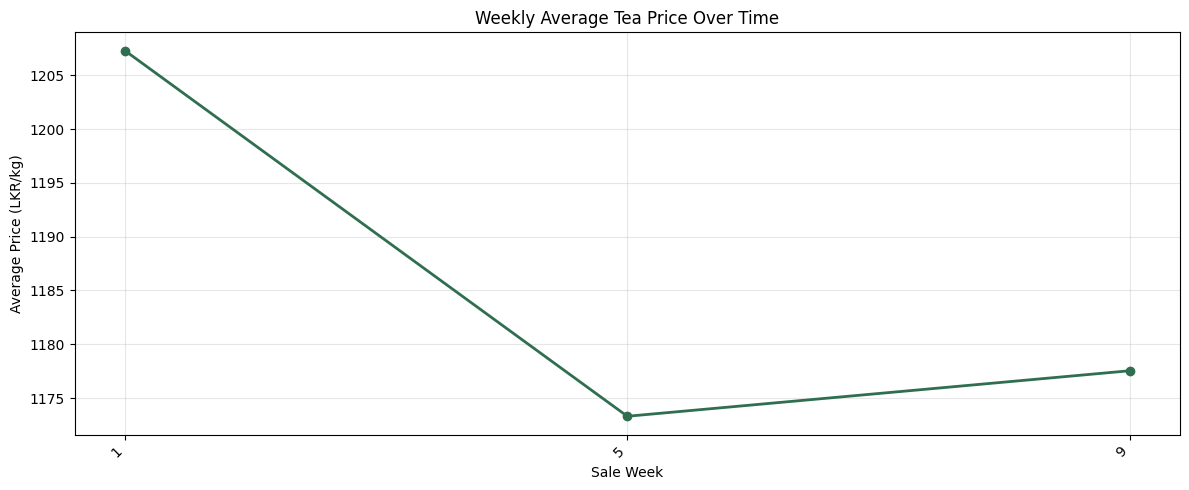

In [66]:
plt.figure(figsize=(12, 5))
plt.plot(
    plot_df['sale_number'],
    plot_df['gross_lkr_weekly_total_2026'],
    marker='o',
    linewidth=2,
    color='#2f6f4f',
)

plt.title('Weekly Average Tea Price Over Time')
plt.xlabel('Sale Week')
plt.ylabel('Average Price (LKR/kg)')
plt.grid(True, alpha=0.3)
plt.xticks(plot_df['sale_number'], rotation=45, ha='right')
plt.tight_layout()
plt.show()